### the problem is supervised for the known and unsupervised for the unknown ones
#### load the dataset
#### train test split
#### tokenization maybe (they are aminoacids so maybe no)
#### Dynamic padding maybe is better than standard padding
#### Evaluation metrics during the training



In [ ]:

!pip install esm
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
from huggingface_hub import login
from huggingface_hub import login
from esm.models.esm3 import ESM3
from esm.sdk.api import ESM3InferenceClient, ESMProtein, GenerationConfig

# login with your Hugging Face credentials
login()



  Cloning https://github.com/Biohub/transformers.git (to revision main) to /tmp/pip-install-hs432usn/transformers_bc495a99582b428db4e6f80be4a7e894
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-install-hs432usn/transformers_bc495a99582b428db4e6f80be4a7e894
  Resolved https://github.com/Biohub/transformers.git to commit ef32577f55da19a4989cd7b22e004dc43a4998cb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install ipywidgets
!pip install  esm@git+https://github.com/Biohub/esm.git@main


  Cloning https://github.com/Biohub/esm.git (to revision main) to /tmp/pip-install-qkxlc45m/esm_0341a9fb37d046cfb9e81f36f2c06304
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/esm.git /tmp/pip-install-qkxlc45m/esm_0341a9fb37d046cfb9e81f36f2c06304
  Resolved https://github.com/Biohub/esm.git to commit d96737e56af90af5f06126955d9dd670db3f930a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Biohub/transformers.git (to revision main) to /tmp/pip-install-qkxlc45m/transformers_69a7a24082724970a4fefd637d2b73fb
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-install-qkxlc45m/transformers_69a7a24082724970a4fefd637d2b73fb
  Resolved https://github.com/Biohub/transformers.git to commit ef32577f55da19a4989cd7b22e004dc43a4998cb
  Installing build dependencies ... done
  Getting requirements to

In [ ]:
!pip install esm@git+https://github.com/Biohub/esm.git@main

#!pip install git+https://github.com/huggingface/transformers.git
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
from transformers import AutoModel, AutoTokenizer
import esm  # registers the esmc architecture with transformers

GFP = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

# optionally use "biohub/ESMC-600M" or "biohub/ESMC-300M"
model = AutoModel.from_pretrained("biohub/ESMC-300M", device_map="cuda").eval()
tokenizer = AutoTokenizer.from_pretrained("biohub/ESMC-300M")

inputs = tokenizer(GFP, return_tensors="pt", padding=True)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.inference_mode():
    output = model(**inputs)

print(f"last_hidden_state shape: {tuple(output.last_hidden_state.shape)}")



  Cloning https://github.com/Biohub/esm.git (to revision main) to /tmp/pip-install-96d5e6fe/esm_b7c6d312125d46c89285f123861b68d7
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/esm.git /tmp/pip-install-96d5e6fe/esm_b7c6d312125d46c89285f123861b68d7
  Resolved https://github.com/Biohub/esm.git to commit d96737e56af90af5f06126955d9dd670db3f930a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Biohub/transformers.git (to revision main) to /tmp/pip-install-96d5e6fe/transformers_7b910c69b41e47e4b8e5ce0170be727a
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-install-96d5e6fe/transformers_7b910c69b41e47e4b8e5ce0170be727a
  Resolved https://github.com/Biohub/transformers.git to commit ef32577f55da19a4989cd7b22e004dc43a4998cb
  Installing build dependencies ... done
  Getting requirements to

Let s try with something smaller first (500 phrogs) till we get the compputational power

In [ ]:
import tarfile
import numpy as np
import pandas as pd
import random

random.seed(42)

annot = pd.read_csv("/content/phrog_annot_v4.tsv", sep="\t")
annot_map = annot.set_index("phrog")["annot"].to_dict()

target_phrogs = set(random.sample(range(1, 38881), 300))
PHROG_sequences = {}

with tarfile.open("/content/FAA_phrog.tar.gz") as t:
    for member in t.getmembers():
        if not member.name.endswith(".faa"):
            continue
        name = member.name.split("/")[-1]
        phrog_id = int(name.replace("phrog_", "").replace(".faa", ""))
        if phrog_id not in target_phrogs:
            continue
        f = t.extractfile(member)
        content = f.read().decode("utf-8")
        seqs = []
        for block in content.split(">")[1:]:
            lines = block.strip().split("\n")
            seq = "".join(lines[1:])
            if len(seq) > 0:
                seqs.append(seq)
        PHROG_sequences[phrog_id] = random.sample(seqs, min(100, len(seqs)))

print(f"PHROGs loaded: {len(PHROG_sequences)}")
print(f"Total sequences: {sum(len(v) for v in PHROG_sequences.values())}")


PHROGs loaded: 300
Total sequences: 3957


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Check file size first — a truncated file will be suspiciously small
import os
size = os.path.getsize("/content/FAA_phrog.tar.gz")

print(f"File size: {size / 1e6:.1f} MB")

File size: 55.5 MB


do proteins of the same function end up close together in the embedding space, even though the model was never told their function?

Attention maps in protein sequence analysis visualize how a machine learning model (usually a Transformer-based Protein Language Model) weighs the relationships between different amino acids. Interpret a sequence and predict its 3D folding and biological function

In [ ]:
from tqdm import tqdm

def embed_batch(model, tokenizer, seqs, batch_size=4):
    all_embs = []
    for i in range(0, len(seqs), batch_size):
        batch = seqs[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            output = model(**inputs)
        hidden = output.last_hidden_state
        attention_mask = inputs["attention_mask"]
        for j in range(len(batch)):
            seq_len = attention_mask[j].sum().item()
            all_embs.append(hidden[j, 1:seq_len - 1].mean(dim=0).cpu().numpy())
    return all_embs


PHROG_embeddings = {}
for phrog_id, seqs in tqdm(sorted(PHROG_sequences.items()), desc="Embedding PHROGs"):
    seq_embs = embed_batch(model, tokenizer, seqs, batch_size=4)
    PHROG_embeddings[phrog_id] = np.mean(seq_embs, axis=0)

print(f"PHROGs embedded: {len(PHROG_embeddings)}")


Embedding PHROGs: 100%|██████████| 300/300 [04:23<00:00,  1.14it/s]

PHROGs embedded: 300


In [ ]:
print(sum(len(v) for v in PHROG_sequences.values()))
print(next(model.parameters()).device)


3957
cuda:0


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

ids = sorted(PHROG_embeddings.keys())
X = np.array([PHROG_embeddings[i] for i in ids])

color_map = annot.set_index("phrog")["color"].to_dict()
colors = [color_map.get(i, "#aaaaaa") for i in ids]

reducer = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=30, alpha=0.8, linewidths=0)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("PHROG embeddings — ESMC-300M zero-shot (n=500)")
plt.tight_layout()
plt.show()


NameError: name 'np' is not defined

In [ ]:
import torch
import random
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForMaskedLM, AutoTokenizer
from torch.optim import AdamW
from tqdm import tqdm



r: Controls the number of trainable parameters in the LoRA adapter matrices. A higher rank increases model capacity but also memory usage.

lora_alpha = Scales the strength of the fine-tuned adjustments in relation to the rank (r)

LoRA Dropout = A regularization technique that randomly sets a fraction of LoRA activations to zero during training to prevent overfitting. Not that useful, so we default set it to 0.



In [ ]:
del model_ft
torch.cuda.empty_cache()


NameError: name 'model_ft' is not defined

In [ ]:
!pip install -q --upgrade torchao

model_ft = AutoModelForMaskedLM.from_pretrained("biohub/ESMC-300M", device_map="cuda", torch_dtype = torch.bfloat16)
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.01,
    target_modules=["layernorm_qkv.1", "out_proj", "ffn.1", "ffn.3"],
)
model_ft = get_peft_model(model_ft, lora_config)
model_ft.print_trainable_parameters()

tokenizer_ft = AutoTokenizer.from_pretrained("biohub/ESMC-300M")
optimizer = AdamW(model_ft.parameters(), lr=1e-4)


trainable params: 230,400 || all params: 333,227,584 || trainable%: 0.0691


In [ ]:
from sklearn.model_selection import train_test_split

all_seqs = [seq for seqs in PHROG_sequences.values() for seq in seqs]
random.shuffle(all_seqs)

train_seqs, val_seqs = train_test_split(all_seqs, test_size=0.2, random_state=42)
print(f"Train: {len(train_seqs)} | Val: {len(val_seqs)}")

def mask_batch(seqs, mask_prob=0.15):
    tokenized = tokenizer_ft(seqs, return_tensors="pt", padding=True)
    input_ids = tokenized["input_ids"].clone()
    attention_mask = tokenized["attention_mask"]
    labels = input_ids.clone()

    special = (
        (input_ids == tokenizer_ft.bos_token_id) |
        (input_ids == tokenizer_ft.eos_token_id) |
        (attention_mask == 0)
    )
    prob_matrix = torch.full(input_ids.shape, mask_prob)
    prob_matrix[special] = 0.0
    masked = torch.bernoulli(prob_matrix).bool()

    for i in range(len(seqs)):
        if not masked[i].any():
            valid = (~special[i]).nonzero(as_tuple=True)[0]
            if len(valid):
                masked[i, valid[random.randint(0, len(valid) - 1)]] = True

    labels[~masked] = -100
    input_ids[masked] = tokenizer_ft.mask_token_id
    return input_ids, attention_mask, labels


Train: 3165 | Val: 792


80 20 train test on the seq - > train on 80% of each PHROGs and the 20% are for the prediction

In [ ]:
batch_size = 1

for epoch in range(10):
    # train
    model_ft.train()
    train_loss = 0
    for i in tqdm(range(0, len(train_seqs), batch_size), desc=f"Epoch {epoch+1} train"):
        batch = train_seqs[i : i + batch_size]
        input_ids, attention_mask, labels = mask_batch(batch)
        input_ids = input_ids.to("cuda")
        attention_mask = attention_mask.to("cuda")
        labels = labels.to("cuda")
        out = model_ft(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        out.loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss += out.loss.item()

    # val
    model_ft.eval()
    val_loss = 0
    with torch.inference_mode():
        for i in tqdm(range(0, len(val_seqs), batch_size), desc=f"Epoch {epoch+1} val"):
            batch = val_seqs[i : i + batch_size]
            input_ids, attention_mask, labels = mask_batch(batch)
            input_ids = input_ids.to("cuda")
            attention_mask = attention_mask.to("cuda")
            labels = labels.to("cuda")
            out = model_ft(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += out.loss.item()

    n_train = len(train_seqs) / batch_size
    n_val = len(val_seqs) / batch_size
    print(f"Epoch {epoch+1} | train loss: {train_loss/n_train:.4f} | val loss: {val_loss/n_val:.4f}")


Epoch 1 val: 100%|██████████| 792/792 [01:19<00:00, 10.02it/s]


Epoch 1 | train loss: 2.2101 | val loss: 2.1335


Epoch 2 val: 100%|██████████| 792/792 [01:19<00:00, 10.00it/s]


Epoch 2 | train loss: 2.1309 | val loss: 2.0548


Epoch 3 val: 100%|██████████| 792/792 [01:19<00:00, 10.00it/s]


...

Epoch 8 | train loss: 1.8159 | val loss: 1.8036


Epoch 9 val: 100%|██████████| 792/792 [01:19<00:00, 10.01it/s]


Epoch 9 | train loss: 1.7797 | val loss: 1.7763


Epoch 10 val: 100%|██████████| 792/792 [01:19<00:00, 10.00it/s]

Epoch 10 | train loss: 1.7416 | val loss: 1.7609


Build the reverse lookup from PHROG_sequences and plot the trained model

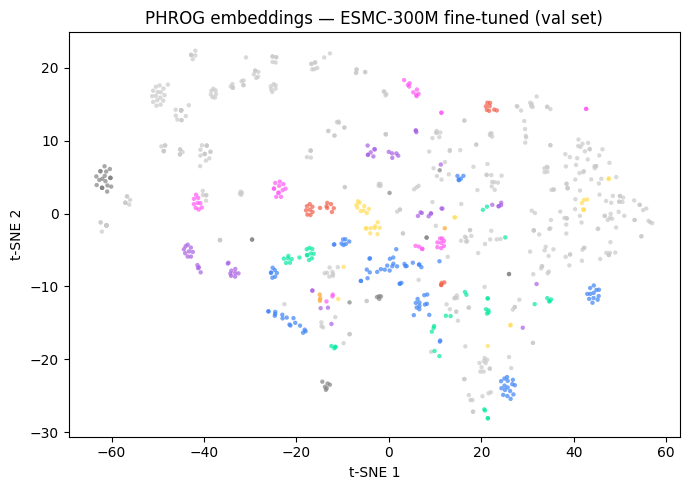

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

seq_to_phrog = {seq: phrog_id for phrog_id, seqs in PHROG_sequences.items() for seq in seqs}
val_ids = [seq_to_phrog.get(seq) for seq in val_seqs]

def embed_batch(model, tokenizer, seqs, batch_size=8):
    all_embs = []
    for i in range(0, len(seqs), batch_size):
        batch = seqs[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            output = model(**inputs, output_hidden_states=True)
        hidden = output.hidden_states[-1]
        mask = inputs["attention_mask"]
        for j in range(len(batch)):
            seq_len = mask[j].sum().item()
            all_embs.append(hidden[j, 1:seq_len - 1].mean(dim=0).cpu().float().numpy())
    return all_embs

model_ft.eval()
val_embs = embed_batch(model_ft, tokenizer_ft, list(val_seqs))
X = np.array(val_embs)
color_map = annot.set_index("phrog")["color"].to_dict()
colors = [color_map.get(pid, "#aaaaaa") for pid in val_ids]

X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=10, alpha=0.7, linewidths=0)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("PHROG embeddings — fine-tuned model (val set)")
plt.tight_layout()
plt.show()